# **Geopandas**

## Loading Libraries

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

## Spatial Data

- Spatial data is simply data that has a location attached to it.
- Regular data tells you what something is. Spatial data tells you what it is AND where it is.

### Types of Spacial Data

1. Vector Data - It describes features on the Earth's Surface using discrete shapes 
    - Points - representing exact locations like hospitals and schools
    - Lines - representing linear deatures like rivers and rail lines
    - Polygons - representing areas like lakes and counties
2. Raster Data - It describes data as a grid of cells, where each cell holds a value 
    - Used for continous phenomena like temperature and elevation

GeoPandas is designed for Vector Data however, with libraries like rasterio it can handle raster data

### File formats for Vector Data

1. Shape file - Most common and comes in 3 files
    - .shp file for the shape geometry
    - .dbf file for attributes
    - .shx file for linking the attributes to the shapes

2. GeoJSON - Single file which is easier to work with

3. KMZ/KML files - Common format used by Google Earth Enine

4. OSM.XML file - NativXML file used by Opera Street map library

In [2]:
kenya = gpd.read_file(r"C:\Users\User\Desktop\Python-class\Data\geoBoundaries-KEN-ADM0_simplified.geojson")
kenya.head()

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Republic of Kenya,KEN,21065076B29129174773383,KEN,ADM0,"MULTIPOLYGON (((39.40649 -4.70221, 39.40747 -4..."


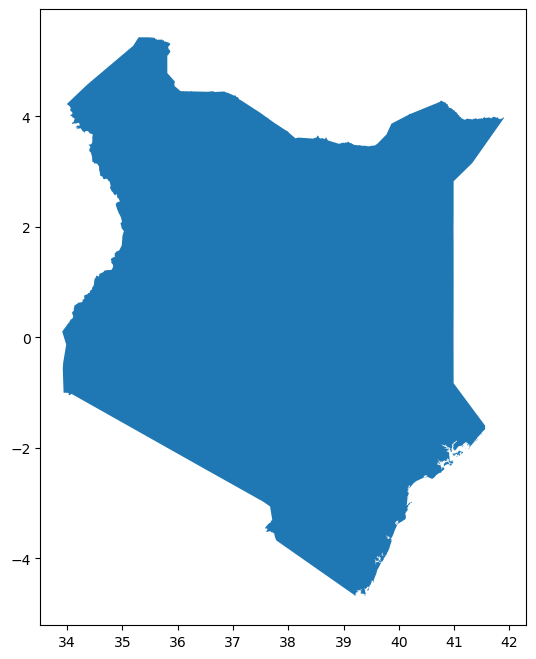

In [10]:
kenya.plot(figsize=(10, 8))
plt.show()

### Using a url 

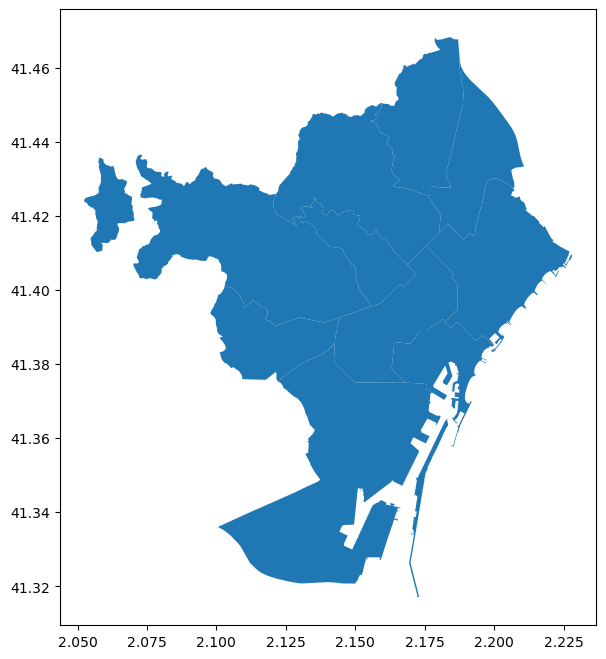

In [ ]:
# If you dont have a file like above
# Use a url to get a map

url = 'https://raw.githubusercontent.com/martgnz/bcn-geodata/refs/heads/master/districtes/districtes.geojson'
barcelona = gpd.read_file(url)
barcelona.plot(figsize=(10,8))
plt.show()

### Creating a GeoDataFrame from Scratch

- To turn coordinates in a spreadsheet into spatial data

In [ ]:
# Don't run it ..will create and save files in your explorer
# The raw data
data = {
    'name': ['Kenyatta Hospital', 'Nairobi Hospital', 'Aga Khan Hospital'],
    'latitude': [-1.3009, -1.2992, -1.2694],
    'longitude': [36.8073, 36.8219, 36.8372]
}

# Step 1 — Create regular DataFrame
df = pd.DataFrame(data)

# Step 2 — Add geometry column
df['geometry'] = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]

# Step 3 — Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

### Saving Spatial Data

In [ ]:
# Don't run it ..will create and save files in your explorer
# Save as GeoJSON
gdf.to_file('hospitals.geojson', driver='GeoJSON')

# Save as Shapefile
gdf.to_file('hospitals.shp')

### Coodinates Reference Systems (CRS)

What is the shape of the earth?

- The Earth is not flat or a perfect sphere — it's a lumpy, uneven mass called a Geoid
- Because the Geoid is too complex, Earth is simplified as an Ellipsoid
- Maps are 2D and flat, so we need a way to translate the 3D Earth onto a flat surface — this is done through projections and CRS

### What is a CRS?

- A Coordinate Reference System (CRS) is the method used to flatten the Earth's 3D surface into a 2D map so every place on Earth can be represented using a set of coordinates.

- Different CRS use different mathematical approaches to flattening, resulting in different coordinate grids.

### Why CRS Matters

If your datasets use different CRS, they will not line up on a map, giving you wrong results. 

Key points:

- Some projections work well for small areas, others for large areas

- Some are better for areas with large East-West extent

- Some are better for areas with large North-South extent

### Components of a CRS

Every CRS has 3 parts:
- **Datum** — defines the shape and size of the Earth being used e.g. WGS 84
- **Projection** — the mathematical method used to flatten the 3D Earth to 2D
- **Coordinate System** — the grid used to locate points (degrees or meters)

### Types of CRS

**1. Geographic CRS**
- Measures location in degrees of latitude and longitude
- Works for the whole world
- Example: EPSG:4326 (WGS 84)
- Best for: displaying maps, global datasets

**2. Projected CRS**
- Measures location in meters or feet on a flat surface
- Works best for specific regions
- Example: EPSG:32637 (UTM Zone 37N) — best for Kenya
- Best for: measuring distances and areas accurately

### What Happens When CRS Don't Match?

If you combine two datasets with different CRS they will not line up on the map.

Example:
- Dataset 1 (food insecurity) uses EPSG:4326
- Dataset 2 (rainfall) uses EPSG:32637

They will appear in completely wrong positions on the map
and eventually give you incorrect analysis and insights.

In [18]:
# Checking the CRS in GeoPandas

# Load Data
kenya = gpd.read_file(r"C:\Users\User\Desktop\Python-class\Data\geoBoundaries-KEN-ADM0_simplified.geojson")

# Check the CRS
kenya.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [25]:
barcelona.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Understanding the CRS Output

When you run kenya.crs you see:

- **EPSG:4326** — the unique ID number for this CRS
- **WGS 84** — World Geodetic System 1984, the global standard used by GPS
- **Lat/Lon in degrees** — coordinates measured in degrees not meters
- **bounds (-180, -90, 180, 90)** — covers the entire Earth
- **Prime Meridian: Greenwich** — 0° longitude passes through London

In [ ]:
# Convert to a different CRS
# inplace=True deletes old geodataframe and creates 
# inplace=False

kenya.to_crs(epsg=21037, inplace=True)

kenya_meters = kenya.to_crs(epsg=21037)

## Spatial Operations

NOTE 
- The source data uses CRS (Degrees)

In [3]:
# Reproject geographic CRS to a projected CRS (meters) for accurate measurements
# EPSG:21037 is a standard projected coordinate system for Kenya using meters

kenya_meters = kenya.to_crs(epsg=21037) # Flattens the map into a meter based grid

### Run a Basic Spatial Operation

### Area Calculation

- The `.area` property returns the surface area

In [4]:
# Calculate the area in square meters 
# Convert it to square kilometers

total_area_km2 = kenya_meters.geometry.area.iloc[0] / 1000000
print(f"Total Land Area of Kenya: {total_area_km2} sq km")

Total Land Area of Kenya: 591352.0935131769 sq km


### Perimeter Calculation

- The `.length` property returns the perimeter for polygons

In [13]:
# Calculate the perimeter in square meters 
# Convert it to kilometers

perimeter_km = kenya_meters.geometry.length.iloc[0] / 1000
print(f"Perimeter of Kenya: {perimeter_km:.2f} km")

Perimeter of Kenya: 5411.97 km


### Extracting Boundaries and Centroids

- The `.boundary` property extracts the outline of the country as a LineString, and `.centroid` calculates the geometric center point

<Axes: >

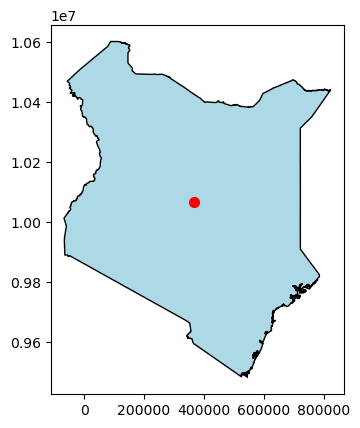

In [5]:
# Extract the national boundary (the outline)

kenya_border = kenya_meters.boundary

# Find the geometric center (centroid)

kenya_center = kenya_meters.centroid

# Plotting the result
ax = kenya_meters.plot(color='lightblue', edgecolor='black')
kenya_center.plot(ax=ax, color='red', markersize=50) # Red dot at the center

### Summary of Overlay Operations:
- Intersection: Returns the overlapping region common to both layers.
- Union: Returns all geometries from both layers, split at intersection points.
- Difference: Returns regions in the first layer that are not in the second.
- Symmetric Difference: Returns regions that are in either layer, but not in both.

### Performing Intersections and Unions (Overlay)

- The `.overlay()` method creates new geometries based on how two map layers overlap.
- Unlike a spatial join (sjoin), which only matches attributes based on location, overlay modifies the geometries by cutting them where they cross.
- **Important:** Both layers must share the **exact same CRS** before performing an overlay
- To try this, we will create a 200km circular buffer around Kenya's center point and see how it interacts with the country's shape

<Axes: >

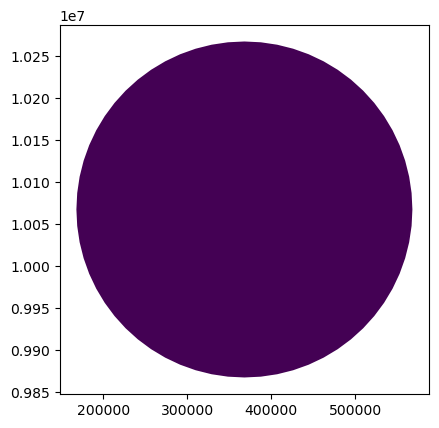

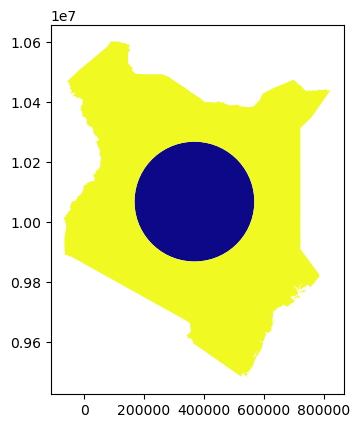

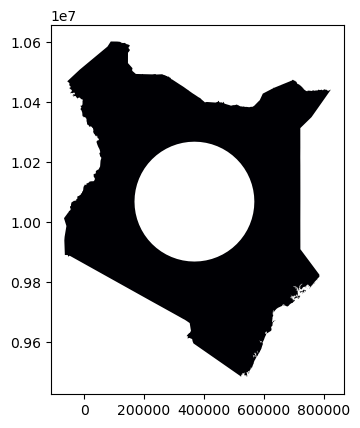

In [6]:
# Create a 200km (200,000 meters) buffer around the center point

center_buffer = kenya_center.buffer(200000) # 200,000 meters
buffer_gdf = gpd.GeoDataFrame(geometry=center_buffer, crs=kenya_meters.crs)

# INTERSECTION: Keep only the part of Kenya INSIDE the 200km buffer

kenya_intersect = kenya_meters.overlay(buffer_gdf, how='intersection')

# UNION: Combine Kenya and the buffer, splitting geometries where they cross
kenya_union = kenya_meters.overlay(buffer_gdf, how='union')

# DIFFERENCE: Keep the parts of Kenya OUTSIDE the 200km buffer
kenya_diff = kenya_meters.overlay(buffer_gdf, how='difference')

# Plot the intersection result
kenya_intersect.plot(cmap='viridis')
kenya_union.plot(cmap="plasma")
kenya_diff.plot(cmap="magma")


### Calculating Distances

- The `.distance()` method finds the minimum distance between two geometries

In [11]:
# Create a random point (example: near Nairobi)

nairobi_point = Point(36.8219, -1.2921)
nairobi_gdf = gpd.GeoDataFrame(geometry=[nairobi_point], crs="EPSG:4326").to_crs(epsg=21037)

# Calculate distance from Nairobi to the national border

dist_to_border = nairobi_gdf.distance(kenya_border.iloc[0])
print(f"Distance to border: {dist_to_border.iloc[0] / 1000:.2f} km")

Distance to border: 123.10 km


### Run a Spatial Overlay (Buffer/Hazard Zone)

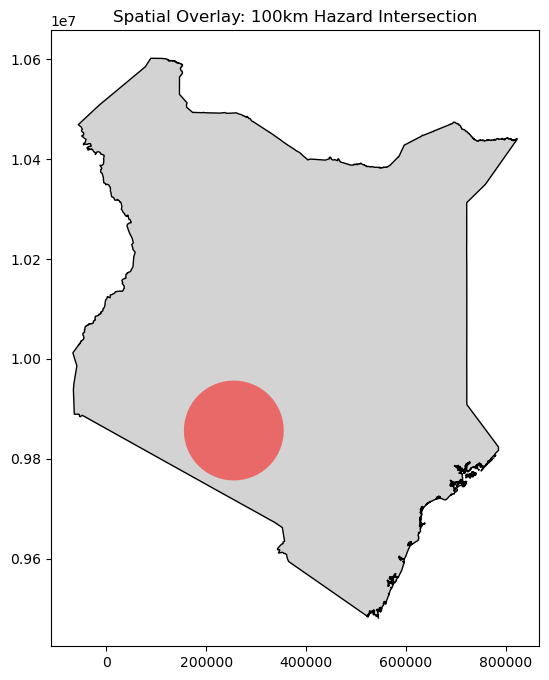

In [12]:
# Create a sample coordinate point near the center of Kenya (Nairobi region)

center_point = gpd.GeoDataFrame(geometry=[Point(36.8, -1.3)], crs="EPSG:4326")
center_point_meters = center_point.to_crs(epsg=21037)

# Draw a 100-kilometer hazard circle around that center point

hazard_buffer = center_point_meters.buffer(100000) # 100,000 meters

# Convert buffer to a GeoDataFrame so we can overlay it

hazard_gdf = gpd.GeoDataFrame(geometry=hazard_buffer, crs="EPSG:21037")

# OVERLAY TIME: Find exactly where the hazard zone sits inside Kenya's boundary

impact_zone = gpd.overlay(kenya_meters, hazard_gdf, how='intersection')

# Plot the visual results for your presentation

fig, ax = plt.subplots(figsize=(10, 8))
kenya_meters.plot(ax=ax, color='lightgray', edgecolor='black')
impact_zone.plot(ax=ax, color='red', alpha=0.5)
ax.set_title("Spatial Overlay: 100km Hazard Intersection")
plt.show()

### Pro-Tip: Handling Topology Errors

- When performing complex overlays, you might encounter a TopologyException due to precision errors.
- You can often fix this by ensuring your geometries are valid using gdf.make_valid() before running the overlay
